In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/twitter_training.csv",
     header=None,
    names=["tweet_id","entity","sentiment","tweet"]
    )


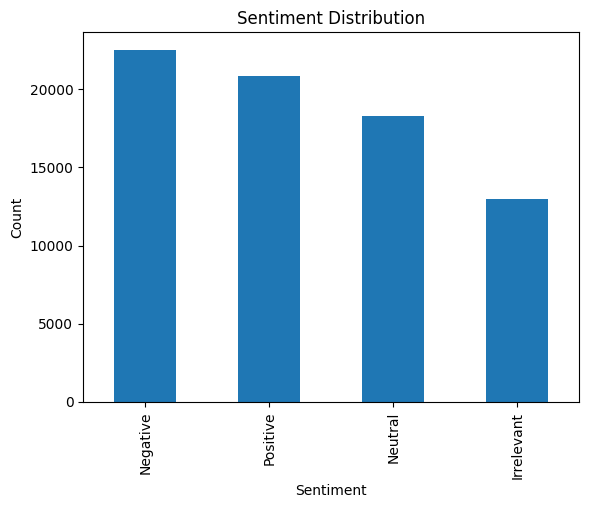

In [2]:
import matplotlib.pyplot as plt 

df["sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [3]:
top_entities = df["entity"].value_counts().head(10)

print(top_entities)

entity
Microsoft                    2400
MaddenNFL                    2400
TomClancysRainbowSix         2400
LeagueOfLegends              2394
CallOfDuty                   2394
Verizon                      2382
CallOfDutyBlackopsColdWar    2376
ApexLegends                  2376
Facebook                     2370
WorldOfCraft                 2364
Name: count, dtype: int64


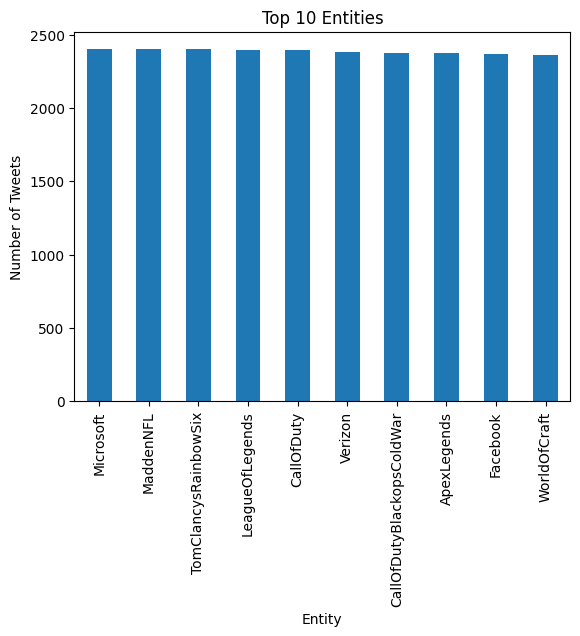

In [4]:
import matplotlib.pyplot as plt

top_entities.plot(kind="bar")

plt.title("Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=90)

plt.show()

In [5]:
df['tweet_length'] = df['tweet'].astype(str).apply(len)
df['tweet_length'].describe()

count    74682.000000
mean       107.811963
std         79.798839
min          1.000000
25%         45.000000
50%         90.000000
75%        152.000000
max        957.000000
Name: tweet_length, dtype: float64

TWEET LENGTH DISTRIBUTION

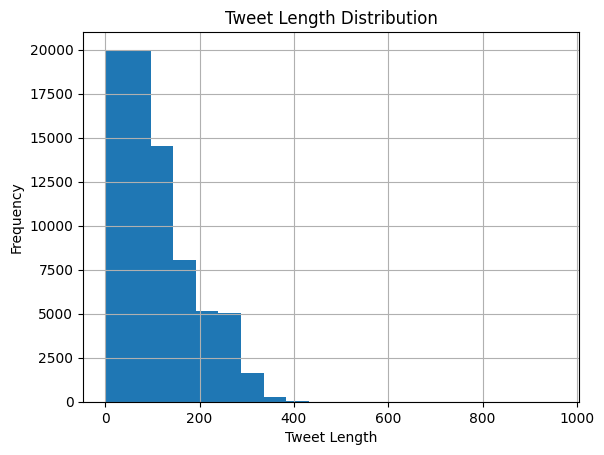

In [6]:
df['tweet_length'].hist(bins=20)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

### Sentiment-wise tweet length:

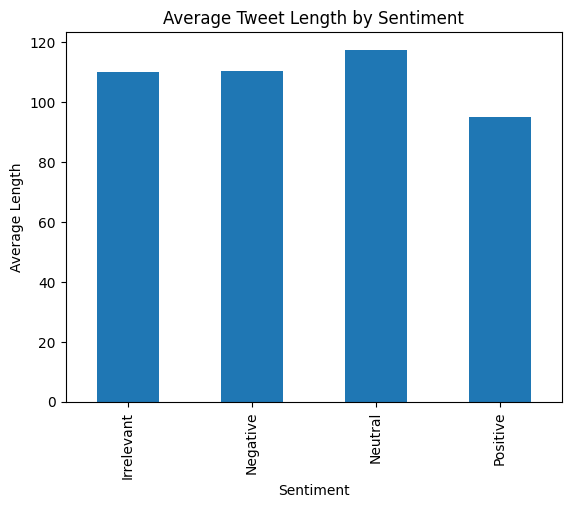

In [7]:
import matplotlib.pyplot as plt

avg_length = df.groupby("sentiment")["tweet_length"].mean()

avg_length.plot(kind="bar")

plt.title("Average Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Length")

plt.show()

In [8]:
df['tweet_length'].describe()

count    74682.000000
mean       107.811963
std         79.798839
min          1.000000
25%         45.000000
50%         90.000000
75%        152.000000
max        957.000000
Name: tweet_length, dtype: float64

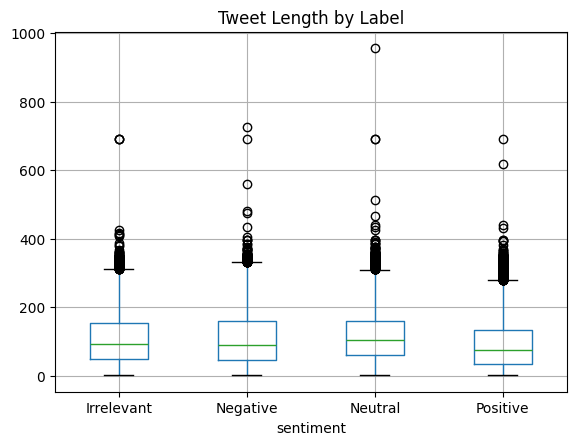

In [9]:
df.boxplot(column='tweet_length', by='sentiment')
plt.title("Tweet Length by Label")
plt.suptitle("")
plt.show()

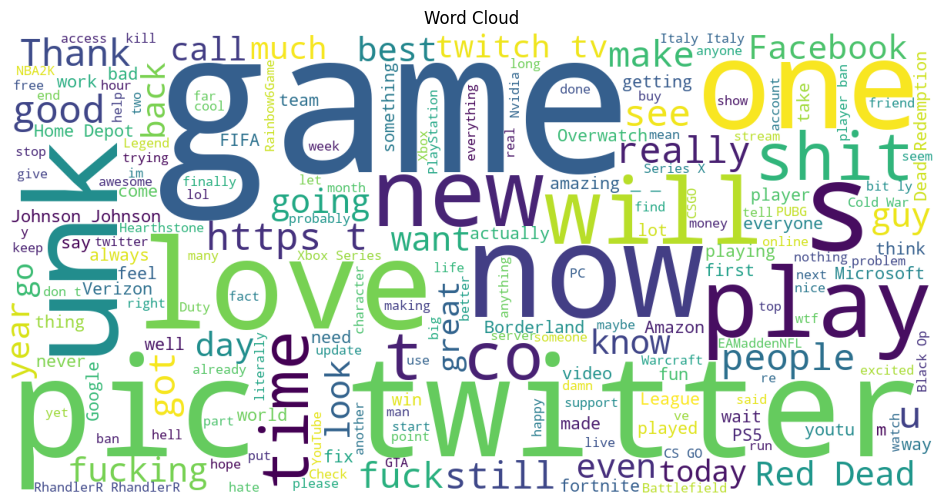

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["tweet"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()